In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# warnings.filterwarnings("ignore")

# 预处理
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler

# 决策树
from sklearn.tree import DecisionTreeClassifier, plot_tree  # 这里已经正确！

# 评估指标
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, precision_recall_curve

In [3]:



train = pd.read_csv("train.csv")    # 训练集：含特征 + 是否生还标签
test = pd.read_csv("test.csv")      # 测试集：只有特征，没有标签

test_ids = test["PassengerId"]      # 保存测试集乘客编号（最后提交必须）


features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]

X_train = train[features].copy()           # 训练集输入特征
X_test = test[features].copy()            # 测试集输入特征
y_train = train["Survived"].copy()         # 训练集标签：0死亡 / 1生还


X_train["Sex"] = X_train["Sex"].map({"male": 0, "female": 1})   # 性别数字化
X_test["Sex"] = X_test["Sex"].map({"male": 0, "female": 1})

# X_train["Embarked"] = X_train["Embarked"].map({"C": 0, "Q": 1, "S": 2}) # 登船口数字化
# X_test["Embarked"] = X_test["Embarked"].map({"C": 0, "Q": 1, "S": 2})

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)


imputer = SimpleImputer(strategy="median")

# imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)  # 训练集：fit + transform
X_val_imp = imputer.transform(X_val)          # 验证集：只 transform
X_test_imp=imputer.transform(X_test)


# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_imp)  # 训练集：学均值方差

# X_val_scaled = scaler.transform(X_val_imp)   
feature_names = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]

# X_train_clean = imputer.fit_transform(X_train)   # 拟合训练集并填充空值
# X_test_clean = imputer.transform(X_test)         # 用训练集规则填充测试集（防止数据泄露）

# scaler = StandardScaler()                        # 标准化器：均值0，方差1
# X_train_scaled = scaler.fit_transform(X_train_clean)  # 训练集标准化
# X_test_scaled = scaler.transform(X_test_clean)        # 测试集按同样规则标准化





In [4]:
# 1. 分裂准则对比
print("===== 分裂准则对比 =====")
for cri, name in zip(["gini", "entropy"], ["基尼", "信息增益"]):
    model = DecisionTreeClassifier(criterion=cri, random_state=42)
    model.fit(X_train_imp, y_train)
    y_pred = model.predict(X_val_imp)
    print(f"{name} 准确率: {accuracy_score(y_val, y_pred):.3f}")

===== 分裂准则对比 =====
基尼 准确率: 0.821
信息增益 准确率: 0.793


In [5]:
dt = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
dt.fit(X_train_imp, y_train)
y_pred = dt.predict(X_val_imp)
y_score = dt.predict_proba(X_val_imp)[:, 1]

In [6]:
# 3. 评估指标
acc = accuracy_score(y_val, y_pred)
pre = precision_score(y_val, y_pred)
rec = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

print("\n===== 模型评估 =====")
print(f"准确率: {acc:.3f}")
print(f"精确率: {pre:.3f}")
print(f"召回率: {rec:.3f}")
print(f"F1: {f1:.3f}")


===== 模型评估 =====
准确率: 0.804
精确率: 0.804
召回率: 0.652
F1: 0.720


In [7]:
sns.set_style("whitegrid")  
# plt.rcParams["font.sans-serif"] = ["SimHei"]  # 正常显示中文
plt.rcParams["axes.unicode_minus"] = False

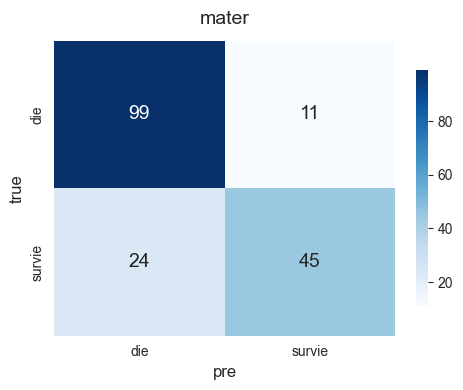

In [8]:
# 1. 混淆矩阵热力图（seaborn 优化）
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["die", "survie"],
    yticklabels=["die", "survie"],
    annot_kws={"size": 14},
    cbar_kws={"shrink": 0.8}
)
plt.title("mater", fontsize=14, pad=12)
plt.xlabel("pre", fontsize=12)
plt.ylabel("true", fontsize=12)
plt.tight_layout()
plt.show()

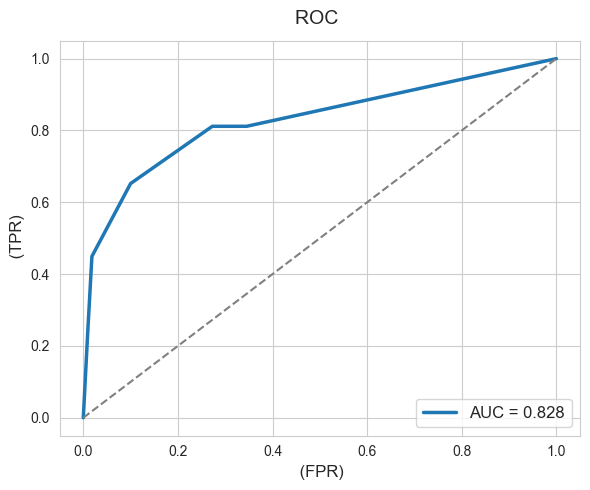

In [9]:
# 2. ROC 曲线（seaborn 风格优化）
fpr, tpr, _ = roc_curve(y_val, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
sns.lineplot(x=fpr, y=tpr, linewidth=2.5, color="#1f77b4", label=f"AUC = {roc_auc:.3f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--", color="gray", linewidth=1.5)
plt.title("ROC ", fontsize=14, pad=12)
plt.xlabel(" (FPR)", fontsize=12)
plt.ylabel(" (TPR)", fontsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.tight_layout()
plt.show()

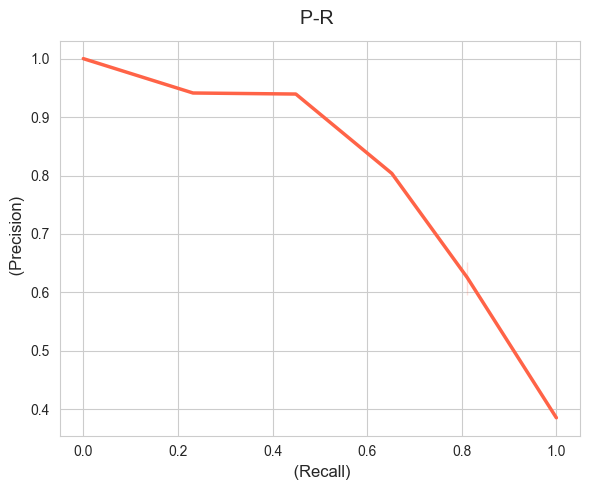

In [10]:
precision, recall, _ = precision_recall_curve(y_val, y_score)

plt.figure(figsize=(6, 5))
sns.lineplot(x=recall, y=precision, linewidth=2.5, color="#ff6347")
plt.title("P-R ", fontsize=14, pad=12)
plt.xlabel(" (Recall)", fontsize=12)
plt.ylabel(" (Precision)", fontsize=12)
plt.tight_layout()
plt.show()

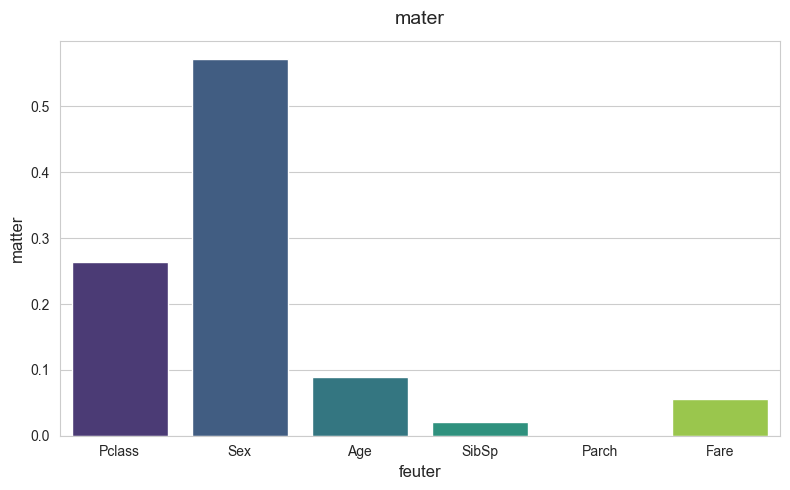

In [11]:
# 4. 特征重要性（seaborn 优化）
plt.figure(figsize=(8, 5))
# 修复警告：加上 hue=x 和 legend=False
sns.barplot(x=feature_names, y=dt.feature_importances_, hue=feature_names, legend=False, palette="viridis")
plt.title("mater", fontsize=14, pad=12)
plt.xlabel("feuter", fontsize=12)
plt.ylabel("matter", fontsize=12)
plt.tight_layout()
plt.show()

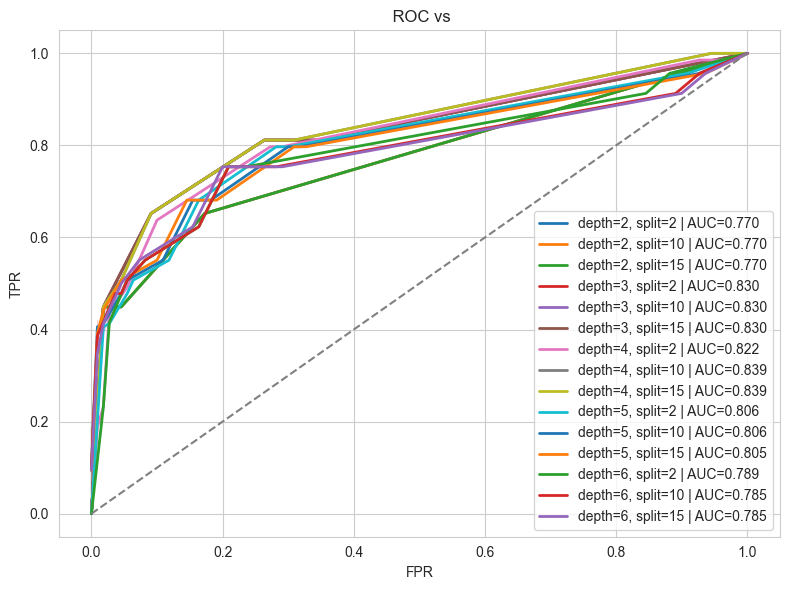

In [12]:
# ==========================
# 双for循环：不同max_depth 和 min_samples_split ROC对比
# ==========================

sns.set_style("whitegrid")
# plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 参数范围
depth_list = [2, 3, 4, 5,6]
split_list = [2,10,15]

plt.figure(figsize=(8, 6))

# 双for循环
for max_depth in depth_list:
    for min_samples_split in split_list:
        
        model = DecisionTreeClassifier(
            criterion="gini",
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=42
        )
        model.fit(X_train_imp, y_train)
        y_score = model.predict_proba(X_val_imp)[:, 1]
        
        fpr, tpr, _ = roc_curve(y_val, y_score)
        auc_score = auc(fpr, tpr)
        
        sns.lineplot(x=fpr, y=tpr, linewidth=2,
                     label=f"depth={max_depth}, split={min_samples_split} | AUC={auc_score:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title(" ROC vs")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

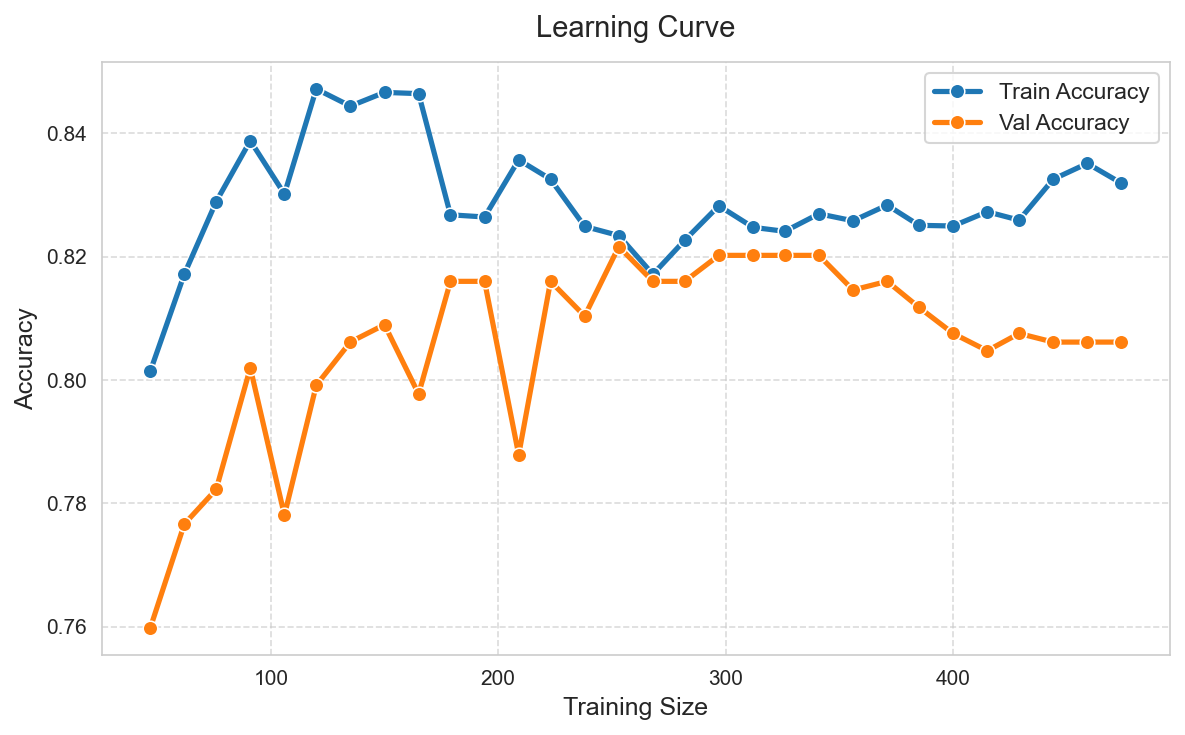

In [18]:
def plot_learning_curve(model, X, y):
    # 风格设置：带网格、干净、好看
    sns.set_style("whitegrid")
    
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, 
        train_sizes=np.linspace(0.1, 1.0, 30),
        cv=3,
        scoring="accuracy"
    )
    
    # 求均值
    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    
    # 画图
    plt.figure(figsize=(8, 5), dpi=150)  # 高清图
    
    # 训练集曲线（蓝色）
    sns.lineplot(
        x=train_sizes, y=train_mean,
        marker='o', markersize=7, linewidth=2.5,
        label="Train Accuracy", color="#1f77b4"
    )
    
    # 验证集曲线（橙色）
    sns.lineplot(
        x=train_sizes, y=val_mean,
        marker='o', markersize=7, linewidth=2.5,
        label="Val Accuracy", color="#ff7f0e"
    )
    
    # 标题与标签
    plt.title("Learning Curve", fontsize=14, pad=12)
    plt.xlabel("Training Size", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)
    
    # 图例 + 网格
    plt.legend(fontsize=11)
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

# 用你当前最好的模型画学习曲线
model = DecisionTreeClassifier(max_depth=3, min_samples_split=10)
plot_learning_curve(model, X_train_imp, y_train)

In [14]:
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    min_samples_split=10,
    random_state=42
)
model.fit(X_train_imp, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [64]:
y_pred = model.predict(X_test_imp)

In [65]:
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": y_pred,
})

In [66]:
submission.to_csv("titanic_knn_result.csv", index=False)